## Cargar datos librerias

In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 73.9 MB/s eta 0:00:00


In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio

In [3]:
punto_Temp = gpd.read_file(r"/content/Estacion_T_max.shp")

In [4]:
punto_Temp.head(3)

,OBJECTID,Id,T_Max,geometry
0,1,1,15.6,POINT (340082.435 8918190.808)
1,2,2,16.9,POINT (352370.646 8919741.876)
2,3,3,22.0,POINT (352412.393 8909321.232)


In [5]:
punto_Temp["X"] = punto_Temp.geometry.x
punto_Temp["Y"] = punto_Temp.geometry.y

In [6]:
# Archivos raster y su descripción
raster_files = {
    "MDE": (r"/content/MDE_UTM.tif", 1),
}

In [7]:
# Crear un DataFrame para almacenar los valores
result_df = punto_Temp.copy()  # Copiar las coordenadas de los puntos
# Iterar sobre los rásteres
for raster_name, (raster_path, num_bands) in raster_files.items():
    with rasterio.open(raster_path) as src:
        # Extraer valores por banda
        for band in range(1, num_bands + 1):  # Las bandas en rasterio comienzan en 1
            values = []
            for _, point in result_df.iterrows():
                coords = [(point.geometry.x, point.geometry.y)]
                try:
                    # Convertir coordenadas a índice de píxel y leer el valor
                    row, col = src.index(coords[0][0], coords[0][1])
                    value = src.read(band)[row, col]
                except IndexError:
                    value = None  # Si el punto está fuera del raster
                values.append(value)
            # Agregar la banda como columna al dataframe
            result_df[f"{raster_name}_B{band}"] = values

In [8]:
result_df.head(4)

,OBJECTID,Id,T_Max,geometry,X,Y,MDE_B1
0,1,1,15.600000,POINT (340082.435 8918190.808),340082.435164,8.918191e+06,4116
1,2,2,16.900000,POINT (352370.646 8919741.876),352370.646297,8.919742e+06,3945
2,3,3,22.000000,POINT (352412.393 8909321.232),352412.392773,8.909321e+06,3105
3,4,4,27.299999,POINT (362969.648 8912362.028),362969.647573,8.912362e+06,2024


In [9]:
result_df.columns

Index(['OBJECTID', 'Id', 'T_Max', 'geometry', 'X', 'Y', 'MDE_B1'], dtype='object')

In [10]:
result_df.columns = ['OBJECTID', 'Id', 'T_Max', 'geometry', 'X', 'Y', 'MDE']

In [11]:
result_df.to_csv("Tabla_extraida_valores.csv",index=False)

## Cargar datos tabla extraida

In [12]:
Tabla = pd.read_csv(r"/content/Tabla_extraida_valores.csv")

In [ ]:
Tabla.head(3)

,OBJECTID,Id,T_Max,geometry,X,Y,MDE,Slope
0,1,1,15.6,POINT (340082.4351640446 8918190.808138518),340082.435164,8.918191e+06,4116,5.813954
1,2,2,16.9,POINT (352370.6462974688 8919741.875831924),352370.646297,8.919742e+06,3945,15.854258
2,3,3,22.0,POINT (352412.39277270157 8909321.231862113),352412.392773,8.909321e+06,3105,20.014850


In [13]:
Tabla.columns

Index(['OBJECTID', 'Id', 'T_Max', 'geometry', 'X', 'Y', 'MDE'], dtype='object')

## Dividir los variables y valores Z

In [14]:
# Dividir en datos de entrenamiento y prueba
X = Tabla[['MDE']]
y = Tabla['T_Max']
xy = Tabla[['X', 'Y']]

In [15]:
y.min()

13.6000003815

In [16]:
y.max()

29.0

In [17]:
# Ajustar modelo de regresión lineal
X1 = Tabla[['MDE','X','Y']]
y1 = Tabla['T_Max']
#xy = Tabla[['ESTE','NORTE']]

In [18]:
!pip install scikit-learn

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test= train_test_split(X1, y1,
                                                    train_size   = 0.8,
                                                    random_state = 42,
                                                    shuffle      = True
                                                   )

In [21]:
len(y_train)

50

In [22]:
XY_train = X_train[["X","Y"]]
XY_test = X_test[["X","Y"]]

In [23]:
X_test1 = X_test[['MDE']]

In [24]:
X_train1 = X_train[['MDE']]

## Seleccionar mejor modelo R2

In [25]:
!pip install statsmodels

In [26]:
import statsmodels.api as sm

### Modelo de Regresión lineal (OLS).

X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.OLS(endog=y_train, exog=X_train)
modelo = modelo.fit()
print(modelo.summary())

In [27]:
X_train2 = sm.add_constant(X_train1, prepend=True)
modelo  = sm.OLS(endog=y_train, exog=X_train2,)
modelo  = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  T_Max   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     2135.
Date:                Wed, 19 Nov 2025   Prob (F-statistic):           1.90e-41
Time:                        23:25:25   Log-Likelihood:                -50.188
No. Observations:                  50   AIC:                             104.4
Df Residuals:                      48   BIC:                             108.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.5593      0.437     92.853      0.0

## Intervalos de confianza para los coeficientes del modelo

In [28]:
# Intervalos de confianza para los coeficientes del modelo
# ==============================================================================
intervalos_ci = modelo.conf_int(alpha=0.05)
intervalos_ci = pd.DataFrame(intervalos_ci)
intervalos_ci.columns = ['2.5%', '97.5%']
intervalos_ci

,2.5%,97.5%
const,39.681059,41.437605
MDE,-0.006286,-0.005761


## Determinar residual en Shapefile

In [29]:
# Residuales
residuals = modelo.resid

In [30]:
len(residuals)

50

In [31]:
len(XY_train)

50

In [32]:
from shapely.geometry import Point

In [33]:
# Convertir residuales a GeoDataFrame
xy_residuales = pd.concat([XY_train, pd.Series(residuals, name="residuals")], axis=1)
xy_residuales["geometry"] = xy_residuales.apply(lambda row: Point(row["X"], row["Y"]), axis=1)
xy_residuales_gdf = gpd.GeoDataFrame(xy_residuales, geometry="geometry", crs="EPSG:32718")

In [34]:
xy_residuales_gdf.head(4)

,X,Y,residuals,geometry
13,387313.711709,8.888211e+06,-0.089079,POINT (387313.712 8888211.029)
34,360066.770698,8.893562e+06,0.049959,POINT (360066.771 8893562.465)
49,342796.237781,8.906202e+06,-0.287450,POINT (342796.238 8906202.262)
3,362969.647573,8.912362e+06,-1.067661,POINT (362969.648 8912362.028)


In [35]:
xy_residuales_gdf["residuals"].max()

1.37414436998883

In [36]:
len(xy_residuales_gdf)

50

In [37]:
xy_residuales_gdf.to_file("Residual_punto.shp")

## Predicciones
Una vez entrenado el modelo, se pueden obtener predicciones para nuevos datos. Los modelos de statsmodels permiten calcular los intervalos de confianza asociados a cada predicción.

In [38]:
# Predicciones con intervalo de confianza
# ==============================================================================
predicciones = modelo.get_prediction(exog=X_train2).summary_frame(alpha=0.05)
predicciones.head(10)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
13,17.989079,0.113812,17.760244,18.217913,16.615047,19.363110
34,23.350041,0.109437,23.130002,23.570079,21.977447,24.722634
49,22.687450,0.103145,22.480064,22.894836,21.316828,24.058072
3,28.367660,0.188305,27.989048,28.746273,26.960911,29.774410
17,15.290527,0.153733,14.981427,15.599627,13.900872,16.680181
48,18.723952,0.105956,18.510913,18.936991,17.352463,20.095441
8,17.796325,0.116146,17.562798,18.029851,16.421505,19.171145
6,27.494245,0.172266,27.147882,27.840609,26.095831,28.892660
33,17.808372,0.115997,17.575145,18.041599,16.433602,19.183142
4,22.127260,0.099140,21.927925,22.326594,20.757832,23.496687


## Coeficiente del modelo

In [39]:
# Guardar coeficientes del modelo
coef_df = pd.DataFrame(modelo.params, columns=["Coeficientes"])

In [40]:
# selected_variables
for var_name in coef_df.index:
    globals()[var_name] = coef_df.loc[var_name, 'Coeficientes']

In [41]:
coef_df.head(10)

,Coeficientes
const,40.559332
MDE,-0.006024


In [42]:
coef_df.to_csv("Coeficiente_LST.csv",index=True)

In [43]:
a1 = coef_df.loc['const','Coeficientes']
a2 = coef_df.loc['MDE','Coeficientes']

## Error de test

In [44]:
from sklearn.metrics import root_mean_squared_error

In [45]:
# Error de test del modelo
# ==============================================================================
X_test2 = sm.add_constant(X_test1, prepend=True)
predicciones = modelo.predict(exog = X_test2)
rmse = root_mean_squared_error(y_true=y_test, y_pred=predicciones)
print(f"El error (rmse) de test es: {rmse}")

El error (rmse) de test es: 0.9604731067941754


## Interpretación

El modelo de regresión lineal:__

Temperatura Max = 40.559332  + (-0.006024) * MDT

es capaz de explicar el 97.8% de la varianza observada en la temperatura (R-squared: 0.978 Adj. R-squared: 0.978). El test  F
  es significativo (p-value: 1.90e-41). Por lo que hay evidencias claras de que el modelo es capaz de explicar la varianza en la temperatura de superficie mejor de lo esperado por azar.

No se satisfacen las condiciones de normalidad, por lo que los intervalos de confianza estimados para los coeficientes y las predicciones no son fiables.

El error (rmse) de test es de 0.9604. Las predicciones del modelo final se alejan en promedio 0.9604 unidades del valor real.

## Agregamos las bandas

In [46]:
import rasterio
import os, glob

In [47]:
os.getcwd()

'/content'

In [48]:
lista_raster = glob.glob("*.tif")
lista_raster

['MDE_UTM.tif']

In [51]:
MDE = rasterio.open(lista_raster[0])


In [52]:
L_MDE = MDE.read(1)

In [53]:
a1

np.float64(40.559331895041176)

In [54]:
Predic_Temp = a1 + a2*L_MDE

In [55]:
Predic_Temp

array([[-156.81443129, -156.81443129, -156.81443129, ..., -156.81443129,
        -156.81443129, -156.81443129],
       [-156.81443129, -156.81443129, -156.81443129, ..., -156.81443129,
        -156.81443129, -156.81443129],
       [-156.81443129, -156.81443129, -156.81443129, ..., -156.81443129,
        -156.81443129, -156.81443129],
       ...,
       [-156.81443129, -156.81443129, -156.81443129, ..., -156.81443129,
        -156.81443129, -156.81443129],
       [-156.81443129, -156.81443129, -156.81443129, ..., -156.81443129,
        -156.81443129, -156.81443129],
       [-156.81443129, -156.81443129, -156.81443129, ..., -156.81443129,
        -156.81443129, -156.81443129]])

In [56]:
# Reemplazar todos los valores menores a -10 por NaN
Predic_Temp1= np.where(Predic_Temp < -10, np.nan, Predic_Temp)

In [57]:
np.nanmin(Predic_Temp1)

np.float64(5.887760470083727)

In [58]:
np.nanmax(Predic_Temp1)

np.float64(30.096420226321392)

## Cambiar tipo de dato

In [59]:
Predic_Temp1.dtype

dtype('float64')

In [60]:
Predic_Temp2 = np.round(Predic_Temp1,3)

In [61]:
Predic_Temp2 = Predic_Temp2.astype("float32")

In [67]:
import matplotlib.pyplot as plt

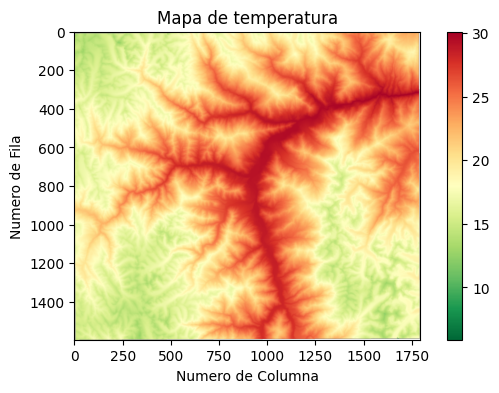

In [68]:
# Ploteamos el resultado
plt.figure(figsize = (7,4))
plt.imshow(Predic_Temp2, cmap='RdYlGn_r') # jet, Spectral, viridis, RdYlGn, hsv, rainbow, reds
plt.colorbar()
plt.title("Mapa de temperatura")
plt.xlabel("Numero de Columna") # etiqueta X
plt.ylabel("Numero de Fila") # etiqueta Y
plt.show()

## Exportar en Raster

In [65]:
param = MDE.meta
param.update(count = 1,
             nodata = None,
             dtype= 'float32')
param

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 1792,
 'height': 1598,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 18S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32718"]]'),
 'transform': Affine(30.91089131578487, 0.0, 334653.3709738964,
        0.0, -30.910891315784394, 8924134.94262736)}

In [66]:
# Exportamos una banda cobertura agua
with rasterio.open("Prediccion_Temperatura.tif", 'w', **param) as DATOS:
    DATOS.write_band(1, Predic_Temp2)